# Monte Carlo LLM
- Modelling Autoregressive Next Token Prediction as a Search Task through Reinforcement Learning
- Using Llama 3.2 1B on Hugging Face

Next Steps:
1. Make an autoregressive word by word "decode" function which yields a list of "word": prob for top k words
2. Generate a graph
3. Generate a graph for top k words for top 3 choices to visualize
4. Implement and visualize temperature either in MatplotLib or in Tree

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

/Users/kyleng/B_Organized/A_School/A_LING_486/code/BERT-Parentheses/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
tokenizer = AutoTokenizer.from_pretrained(
            "meta-llama/Llama-3.2-1B")
model = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-3.2-1B")

In [ ]:
class DecoderLLM():
    def __init__(self, verbose: bool = True):
        self.tokenizer = tokenizer
        self.model = model
        self.verbose = verbose

    def generate_next_logits(self, prompt: str) -> torch.tensor:
        tokenized_input = self.tokenizer(prompt, return_tensors="pt").input_ids

        if (self.verbose):
            print(f"Generating next logits for prompt: {prompt}")
            print(f"\tTokenizing {prompt}: {tokenized_input.shape}")

        with torch.no_grad():
            output = self.model(tokenized_input)

        output_logits = torch.squeeze(output.logits)
        last_logits = output_logits[-1]

        if (self.verbose):
            print(f"\tShape of LLM output: {output_logits.shape}")
            print(f"\tPredicted Logits: {last_logits}")
        return last_logits

    def softmax(self, logits: torch.tensor, temperature: float = 1.0) -> torch.tensor:
        exp_logits = torch.exp(logits/temperature)
        softmax_probs = exp_logits/torch.sum(exp_logits)

        if (self.verbose):
            print(f"Softmax probs: {softmax_probs}")
        return softmax_probs

    def decode_probs(self, probs: torch.tensor, top_k: int = 3, bottom_k: int = 3) -> list[tuple[str, torch.tensor]]:
        top_probs, top_idxs = torch.topk(probs, top_k)
        min_probs, min_idxs = torch.topk(-1 * probs, bottom_k)

        output = []
        for prob, idx in zip(top_probs, top_idxs):
            output.append(
                (self.tokenizer.decode(idx), prob)
            )
        
        # technically this is the bottom 3 reversed but the probabilites are so low it doesn't matter!
        for prob, idx in zip(min_probs, min_idxs):
            output.append(
                (self.tokenizer.decode(idx), -1*prob)
            )
        return output

In [73]:
llm = DecoderLLM()

In [74]:
logits = llm.generate_next_logits(prompt="The children went out to")
prob = llm.softmax(logits)

print(f"Santiy check, softmax probs sums to 1.0: {torch.sum(prob)}")

llm.decode_probs(prob, top_k=3)

Generating next logits for prompt: The children went out to
	Tokenizing The children went out to: torch.Size([1, 6])
	Shape of LLM output: torch.Size([6, 128256])
	Predicted Logits: tensor([6.0178, 8.3588, 5.0207,  ..., 0.2099, 0.2095, 0.2090])
Softmax probs: tensor([1.2274e-07, 1.2756e-06, 4.5286e-08,  ..., 3.6868e-10, 3.6855e-10,
        3.6837e-10])
Santiy check, softmax probs sums to 1.0: 0.9999998807907104


[(' play', tensor(0.2767)),
 (' the', tensor(0.2152)),
 (' see', tensor(0.0312)),
 ('之一', tensor(3.5027e-12)),
 ('entered', tensor(9.3048e-12)),
 ('瞬', tensor(1.0087e-11))]

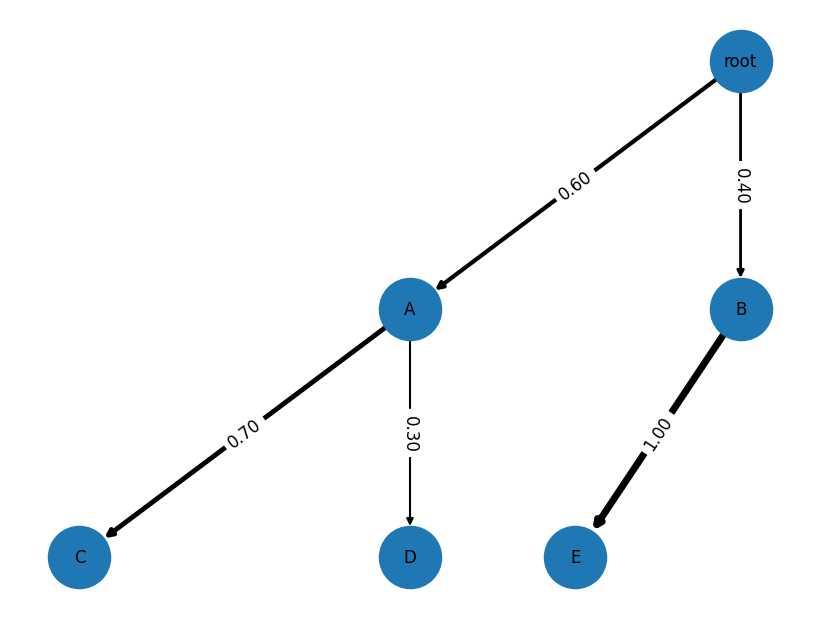

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_search_tree(tree, root="root"):
    G = nx.DiGraph()
    pos = {}  # Node positions
    labels = {}  # Node labels
    edge_widths = {}  # Edge thickness (dict for labeling)

    def build_graph(node, depth=0, x=0):
        pos[node] = (x, -depth)
        labels[node] = node
        children = tree.get(node, [])
        spread = len(children) / 2  # Spreading out child nodes

        for i, (child, prob) in enumerate(children):
            x_child = x + (i - spread)
            G.add_edge(node, child)
            edge_widths[(node, child)] = prob  # Store probability for edge labels
            build_graph(child, depth + 1, x_child)

    build_graph(root)

    plt.figure(figsize=(8, 6))
    edges = G.edges()
    widths = [edge_widths[e] * 5 for e in edges]  # Scale thickness
    nx.draw(G, pos, labels=labels, with_labels=True, node_size=2000, edge_color="black", width=widths, edge_cmap=plt.cm.Blues)

    # Add edge labels
    edge_labels = {e: f"{edge_widths[e]:.2f}" for e in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

    plt.show()

# Example tree structure
tree = {
    "root": [("A", 0.6), ("B", 0.4)],
    "A": [("C", 0.7), ("D", 0.3)],
    "B": [("E", 1.0)],
    "C": [],
    "D": [],
    "E": []
}

draw_search_tree(tree)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B")

# Encode input text
input_text = "Once upon a time"
input_ids = tokenizer(input_text, return_tensors="pt").input_ids

# Get model logits (raw scores)
with torch.no_grad():
    outputs = model(input_ids)
    logits = outputs.logits  # Shape: (batch_size, sequence_length, vocab_size)

# Extract the logits for the last token
last_token_logits = logits[:, -1, :]  # Shape: (1, vocab_size)

# Convert logits to probabilities using softmax
probs = F.softmax(last_token_logits, dim=-1)  # Shape: (1, vocab_size)

# Get the top 10 most likely tokens and their probabilities
top_k = 10
top_probs, top_indices = torch.topk(probs, top_k)

# Decode tokens and print probabilities
for token_id, prob in zip(top_indices[0], top_probs[0]):
    print(f"{tokenizer.decode([token_id.item()])}: {prob.item():.4f}")
